In [8]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST CSV
file_path = "mnist_test.csv"  # Replace with your actual file path
mnist_data = pd.read_csv(file_path)

# Choose a random row index (skip the first column, which is the label)
random_index = np.random.randint(0, len(mnist_data))  # Random index from 0 to len(dataset)-1

# Extract the selected row and reshape it to 28x28
random_image = mnist_data.iloc[random_index, 1:].values.reshape(28, 28).astype(np.uint8)  # Skip label column

# Convert to Pillow Image
img = Image.fromarray(random_image)

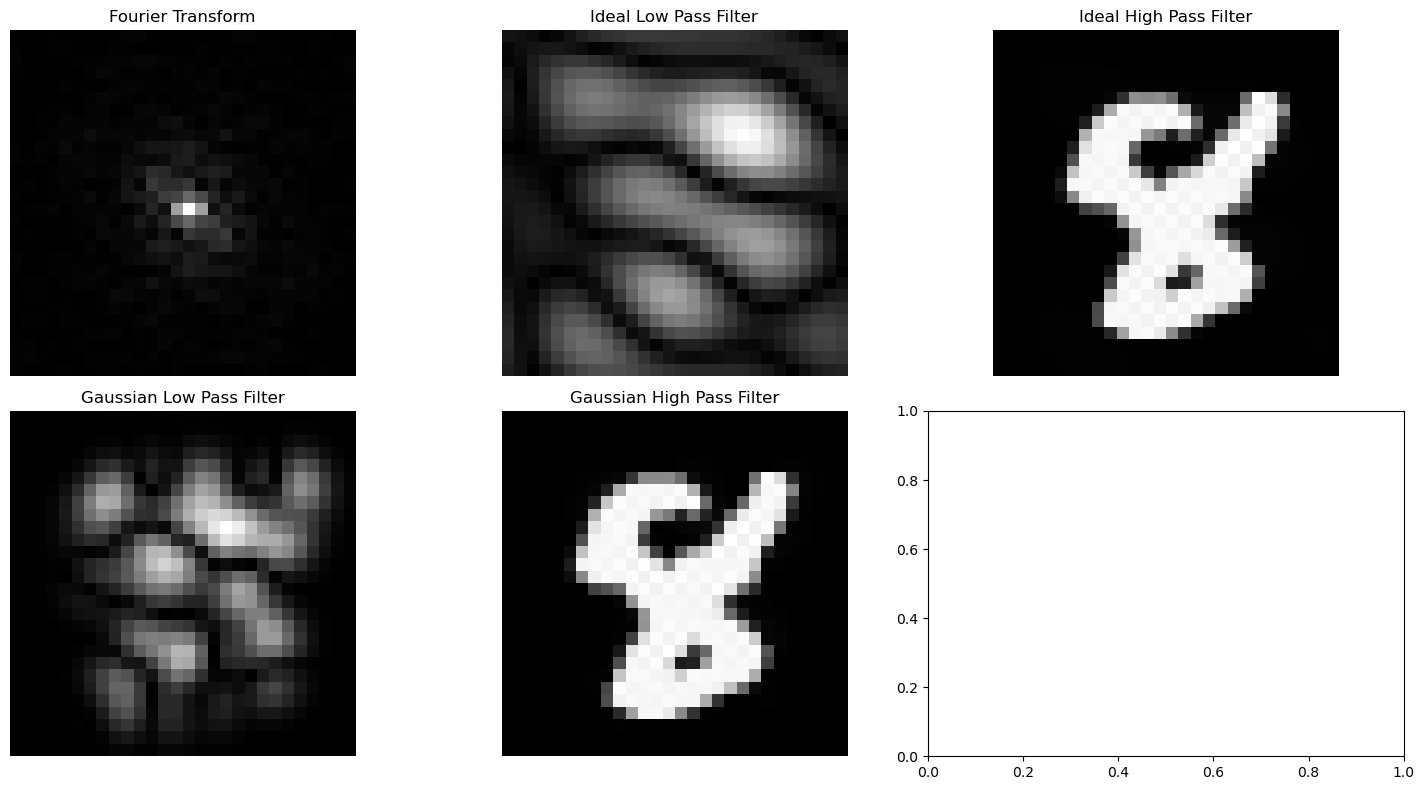

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2

# Fourier Transform with centering
def fourier_transform(image):
    rows, cols = image.shape
    # Center the image
    centered_image = image * (-1)**(np.arange(rows)[:, None] + np.arange(cols))
    fourier_transformed_image = fft2(centered_image)
    return fourier_transformed_image

# Ideal Low Pass Filter
def ideal_low_pass_filter(fourier_image, cutoff_radius):
    rows, cols = fourier_image.shape
    u = np.fft.fftfreq(cols, 1)  # Frequency bins in x-direction
    v = np.fft.fftfreq(rows, 1)  # Frequency bins in y-direction
    U, V = np.meshgrid(u, v)
    distance = np.sqrt(U**2 + V**2)
    low_pass_mask = distance <= cutoff_radius
    filtered_image = fourier_image * low_pass_mask
    return np.abs(ifft2(filtered_image))

# Ideal High Pass Filter
def ideal_high_pass_filter(fourier_image, cutoff_radius):
    rows, cols = fourier_image.shape
    u = np.fft.fftfreq(cols, 1)
    v = np.fft.fftfreq(rows, 1)
    U, V = np.meshgrid(u, v)
    distance = np.sqrt(U**2 + V**2)
    high_pass_mask = distance >= cutoff_radius
    filtered_image = fourier_image * high_pass_mask
    return np.abs(ifft2(filtered_image))

# Gaussian Low Pass Filter
def gaussian_low_pass_filter(fourier_image, cutoff_radius):
    rows, cols = fourier_image.shape
    u = np.fft.fftfreq(cols, 1)
    v = np.fft.fftfreq(rows, 1)
    U, V = np.meshgrid(u, v)
    distance = np.sqrt(U**2 + V**2)
    gaussian_mask = np.exp(-distance**2 / (2 * cutoff_radius**2))
    filtered_image = fourier_image * gaussian_mask
    return np.abs(ifft2(filtered_image))

# Gaussian High Pass Filter
def gaussian_high_pass_filter(fourier_image, cutoff_radius):
    rows, cols = fourier_image.shape
    u = np.fft.fftfreq(cols, 1)
    v = np.fft.fftfreq(rows, 1)
    U, V = np.meshgrid(u, v)
    distance = np.sqrt(U**2 + V**2)
    gaussian_mask = 1 - np.exp(-distance**2 / (2 * cutoff_radius**2))
    filtered_image = fourier_image * gaussian_mask
    return np.abs(ifft2(filtered_image))

# Ensure the image is a NumPy array
img_array = np.array(img)  # Convert PIL image to NumPy array

# Fourier Transform
ft_image = fourier_transform(img_array)

# Apply filters
low_pass_result = ideal_low_pass_filter(ft_image, 0.1)
high_pass_result = ideal_high_pass_filter(ft_image, 0.1)
gaussian_low_pass_result = gaussian_low_pass_filter(ft_image, 0.1)
gaussian_high_pass_result = gaussian_high_pass_filter(ft_image, 0.1)

# Plot results
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(np.abs(ft_image), cmap='gray')
axes[0, 0].set_title("Fourier Transform")
axes[0, 0].axis('off')

axes[0, 1].imshow(low_pass_result, cmap='gray')
axes[0, 1].set_title("Ideal Low Pass Filter")
axes[0, 1].axis('off')

axes[0, 2].imshow(high_pass_result, cmap='gray')
axes[0, 2].set_title("Ideal High Pass Filter")
axes[0, 2].axis('off')

axes[1, 0].imshow(gaussian_low_pass_result, cmap='gray')
axes[1, 0].set_title("Gaussian Low Pass Filter")
axes[1, 0].axis('off')

axes[1, 1].imshow(gaussian_high_pass_result, cmap='gray')
axes[1, 1].set_title("Gaussian High Pass Filter")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
